> 수작업한 라벨 전처리 (NULL, 불필요한 행 제거)

> 수작업한 라벨이 실제 이미지 데이터와 매칭되는지 확인

In [2]:
# =====================
# 0. 라이브러리 설치
# =====================
import subprocess
subprocess.run(['pip', 'install', 'ultralytics', '-q'])

import os
import pandas as pd

# =====================
# 1. 라벨 로드 및 정제
# =====================
train_label = pd.read_csv('/kaggle/input/datasets/hyunseo2/boar-label/train.csv')
train_label = train_label[train_label['label'].isin(['0', '1'])]
train_label['label'] = train_label['label'].astype(int)
train_label = train_label[['name', 'label']].reset_index(drop=True)
print(f"Train: {train_label.shape}")
print(train_label['label'].value_counts())

val_label = pd.read_csv('/kaggle/input/datasets/hyunseo2/boar-label/val.csv')
val_label = val_label[val_label['label'].isin(['0', '1'])]
val_label['label'] = val_label['label'].astype(int)
val_label = val_label[['name', 'label']].reset_index(drop=True)
print(f"\nVal: {val_label.shape}")
print(val_label['label'].value_counts())

# =====================
# 2. 이미지 경로 확인
# =====================
ts_path = '/kaggle/input/datasets/hyejeong12/boar-train/TS_02.'
vs_path = '/kaggle/input/datasets/hyunseo2/boar-val/VS_02.'

train_exist = train_label['name'].apply(lambda x: os.path.exists(os.path.join(ts_path, x)))
val_exist = val_label['name'].apply(lambda x: os.path.exists(os.path.join(vs_path, x)))

print(f"\nTrain 이미지 존재: {train_exist.sum()}/{len(train_label)}")
print(f"Val 이미지 존재: {val_exist.sum()}/{len(val_label)}")
print("===== 세팅 완료 =====")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 48.8 MB/s eta 0:00:00
Train: (1312, 2)
label
1    707
0    605
Name: count, dtype: int64

Val: (326, 2)
label
1    179
0    147
Name: count, dtype: int64

Train 이미지 존재: 1312/1312
Val 이미지 존재: 326/326
===== 세팅 완료 =====


> 훈련 전 세팅

In [3]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from PIL import Image
import os
import json

class BoarDataset(Dataset):
    def __init__(self, df, img_dir, label_dir, transform=None):
        self.df = df.reset_index(drop=True)
        self.img_dir = img_dir        # 이미지 폴더 경로
        self.label_dir = label_dir    # JSON 라벨 폴더 경로
        self.transform = transform    # 전처리 함수

    def __len__(self):
        # 전체 데이터 수 반환
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_name = row['name']
        label = int(row['label'])  # 0: 그외, 1: 훼손중

        # 이미지 로드
        img_path = os.path.join(self.img_dir, img_name)
        img = Image.open(img_path).convert('RGB')

        # JSON에서 바운딩박스 읽어서 멧돼지 영역만 크롭
        json_name = img_name.replace('.jpg', '.json')
        json_path = os.path.join(self.label_dir, json_name)

        if os.path.exists(json_path):
            with open(json_path, 'r') as f:
                data = json.load(f)
            bbox = data['annotations'][0]['bbox']
            x1, y1 = int(bbox[0][0]), int(bbox[0][1])  # 좌상단 좌표
            x2, y2 = int(bbox[1][0]), int(bbox[1][1])  # 우하단 좌표
            img = img.crop((x1, y1, x2, y2))           # 멧돼지 영역 크롭

        if self.transform:
            img = self.transform(img)

        return img, label

# train용 전처리 (증강 포함)
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),              # EfficientNet 입력 크기
    transforms.RandomHorizontalFlip(),          # 좌우 반전 (50% 확률)
    transforms.ColorJitter(brightness=0.3, contrast=0.3),  # 밝기/대비 조정
    transforms.ToTensor(),                      # PIL 이미지 → 텐서
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])  # ImageNet 정규화
])

# val용 전처리 (증강 없음)
val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# 경로 설정
ts_path = '/kaggle/input/datasets/hyejeong12/boar-train/TS_02.'  # train 이미지
vs_path = '/kaggle/input/datasets/hyunseo2/boar-val/VS_02.'      # val 이미지
tl_path = '/kaggle/input/datasets/hyejeong12/boar-train/TL_02.'  # train JSON
vl_path = '/kaggle/input/datasets/hyunseo2/boar-val/VL_02.'      # val JSON

# 데이터셋 생성
train_dataset = BoarDataset(train_label, ts_path, tl_path, train_transform)
val_dataset = BoarDataset(val_label, vs_path, vl_path, val_transform)

# 데이터로더 생성 (배치 단위로 데이터 공급)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=2)

print(f"Train 배치 수: {len(train_loader)}")
print(f"Val 배치 수: {len(val_loader)}")

Train 배치 수: 41
Val 배치 수: 11


> 학습 시작

In [4]:
# GPU/CPU 디바이스 설정
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"사용 디바이스: {device}")

# EfficientNet-B0 로드 (ImageNet 사전학습 가중치)
# 마지막 분류층을 이진 분류(1개 출력)로 교체
model2b = models.efficientnet_b0(weights='IMAGENET1K_V1')
model2b.classifier[1] = nn.Linear(model2b.classifier[1].in_features, 1)
model2b = model2b.to(device)

# 손실함수: 이진 분류용 BCEWithLogitsLoss
criterion = nn.BCEWithLogitsLoss()

# 옵티마이저: Adam (학습률 0.001)
optimizer = torch.optim.Adam(model2b.parameters(), lr=0.001)

# 스케줄러: val loss가 개선 없으면 학습률 절반으로 감소
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=5, factor=0.5)

best_val_acc = 0
patience_counter = 0
patience = 15  # 15에폭 동안 개선 없으면 조기 종료

for epoch in range(100):
    # ---- Train 단계 ----
    model2b.train()
    train_loss, train_correct = 0, 0
    for imgs, labels in train_loader:
        imgs = imgs.to(device)
        labels = labels.float().to(device)

        optimizer.zero_grad()           # 이전 gradient 초기화
        outputs = model2b(imgs).squeeze(1)
        loss = criterion(outputs, labels)
        loss.backward()                 # gradient 계산
        optimizer.step()                # 파라미터 업데이트

        train_loss += loss.item()
        preds = (torch.sigmoid(outputs) > 0.5).long()  # 0.5 이상이면 1로 분류
        train_correct += (preds == labels.long()).sum().item()

    # ---- Val 단계 ----
    model2b.eval()
    val_loss, val_correct = 0, 0
    with torch.no_grad():  # gradient 계산 안 함 (추론만)
        for imgs, labels in val_loader:
            imgs = imgs.to(device)
            labels = labels.float().to(device)
            outputs = model2b(imgs).squeeze(1)
            loss = criterion(outputs, labels)
            val_loss += loss.item()
            preds = (torch.sigmoid(outputs) > 0.5).long()
            val_correct += (preds == labels.long()).sum().item()

    train_acc = train_correct / len(train_dataset)
    val_acc = val_correct / len(val_dataset)

    print(f"Epoch {epoch+1}/100 | Train Loss: {train_loss/len(train_loader):.4f} | Train Acc: {train_acc:.4f} | Val Loss: {val_loss/len(val_loader):.4f} | Val Acc: {val_acc:.4f}")

    scheduler.step(val_loss)

    # Best 모델 저장 및 Early Stopping
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model2b.state_dict(), '/kaggle/working/model2b_best.pth')
        patience_counter = 0
        print(f"  → Best 모델 저장 (Val Acc: {val_acc:.4f})")
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f"Early stopping at epoch {epoch+1}")
            break

print(f"최고 Val Accuracy: {best_val_acc:.4f}")

사용 디바이스: cuda
Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 224MB/s]


Epoch 1/100 | Train Loss: 0.3227 | Train Acc: 0.8582 | Val Loss: 0.4382 | Val Acc: 0.8681
  → Best 모델 저장 (Val Acc: 0.8681)
Epoch 2/100 | Train Loss: 0.1283 | Train Acc: 0.9512 | Val Loss: 1.1813 | Val Acc: 0.7577
Epoch 3/100 | Train Loss: 0.1061 | Train Acc: 0.9588 | Val Loss: 0.5729 | Val Acc: 0.8466
Epoch 4/100 | Train Loss: 0.0884 | Train Acc: 0.9710 | Val Loss: 0.7051 | Val Acc: 0.8405
Epoch 5/100 | Train Loss: 0.0559 | Train Acc: 0.9794 | Val Loss: 0.5128 | Val Acc: 0.8466
Epoch 6/100 | Train Loss: 0.0385 | Train Acc: 0.9878 | Val Loss: 0.4566 | Val Acc: 0.8681
Epoch 7/100 | Train Loss: 0.0426 | Train Acc: 0.9840 | Val Loss: 0.6053 | Val Acc: 0.8558
Epoch 8/100 | Train Loss: 0.0214 | Train Acc: 0.9924 | Val Loss: 0.5473 | Val Acc: 0.8497
Epoch 9/100 | Train Loss: 0.0077 | Train Acc: 0.9985 | Val Loss: 0.6409 | Val Acc: 0.8466
Epoch 10/100 | Train Loss: 0.0086 | Train Acc: 0.9962 | Val Loss: 0.6603 | Val Acc: 0.8466
Epoch 11/100 | Train Loss: 0.0073 | Train Acc: 0.9977 | Val Loss: 

In [5]:
import shutil
shutil.copy('/kaggle/working/model2b_best.pth', '/kaggle/working/model2b_best_final.pth')
print("저장 완료")

저장 완료


> 잘 나오나 성능 확인!

예측: 그외 (0)
확률: 0.0014


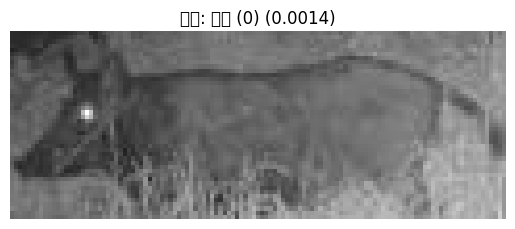

In [10]:
from ultralytics import YOLO
import matplotlib.pyplot as plt

model1 = YOLO('/kaggle/input/datasets/hyunseo2/boarsommelier-models1/boar_detection_best.pt')
img_path = '/kaggle/input/datasets/hyunseo2/boar-testimg/boar.jpg'

results = model1(img_path, verbose=False)
boxes = results[0].boxes

if boxes is not None and len(boxes) > 0:
    x1, y1, x2, y2 = map(int, boxes.xyxy[0].cpu().numpy())
    
    img = Image.open(img_path).convert('RGB')
    img_cropped = img.crop((x1, y1, x2, y2))
    
    img_tensor = transform(img_cropped).unsqueeze(0).to(device)
    with torch.no_grad():
        output = model2b(img_tensor)
        prob = torch.sigmoid(output).item()
        pred = 1 if prob > 0.5 else 0
    
    print(f"예측: {'훼손중 (1)' if pred == 1 else '그외 (0)'}")
    print(f"확률: {prob:.4f}")
    
    # 이미지 출력
    plt.imshow(img_cropped)
    plt.title(f"예측: {'훼손중 (1)' if pred == 1 else '그외 (0)'} ({prob:.4f})")
    plt.axis('off')
    plt.show()
else:
    print("멧돼지 탐지 실패")

예측: 그외 (0)
확률: 0.0000


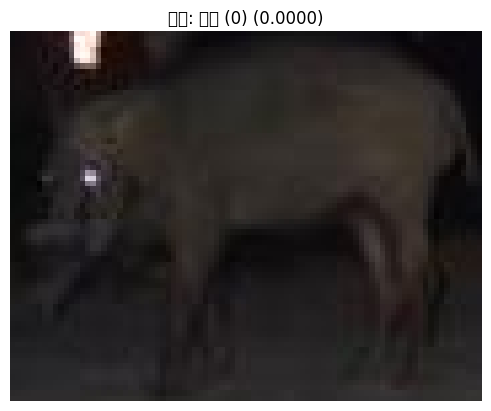

In [11]:
from ultralytics import YOLO
import matplotlib.pyplot as plt

model1 = YOLO('/kaggle/input/datasets/hyunseo2/boarsommelier-models1/boar_detection_best.pt')
img_path = '/kaggle/input/datasets/hyunseo2/boar-testimg/boar2.jpg'

results = model1(img_path, verbose=False)
boxes = results[0].boxes

if boxes is not None and len(boxes) > 0:
    x1, y1, x2, y2 = map(int, boxes.xyxy[0].cpu().numpy())
    
    img = Image.open(img_path).convert('RGB')
    img_cropped = img.crop((x1, y1, x2, y2))
    
    img_tensor = transform(img_cropped).unsqueeze(0).to(device)
    with torch.no_grad():
        output = model2b(img_tensor)
        prob = torch.sigmoid(output).item()
        pred = 1 if prob > 0.5 else 0
    
    print(f"예측: {'훼손중 (1)' if pred == 1 else '그외 (0)'}")
    print(f"확률: {prob:.4f}")
    
    # 이미지 출력
    plt.imshow(img_cropped)
    plt.title(f"예측: {'훼손중 (1)' if pred == 1 else '그외 (0)'} ({prob:.4f})")
    plt.axis('off')
    plt.show()
else:
    print("멧돼지 탐지 실패")

예측: 훼손중 (1)
확률: 0.9515


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 55036 (\N{HANGUL SYLLABLE HWE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 49552 (\N{HANGUL SYLLABLE SON}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 51473 (\N{HANGUL SYLLABLE JUNG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


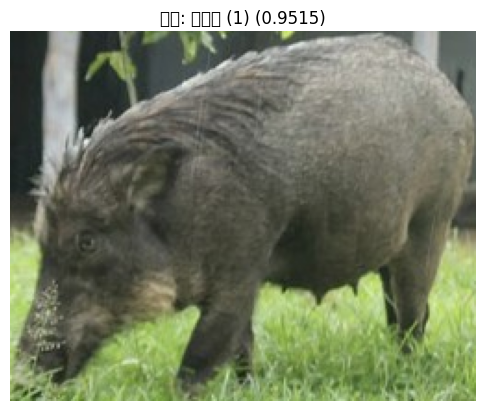

In [13]:
from ultralytics import YOLO
import matplotlib.pyplot as plt

model1 = YOLO('/kaggle/input/datasets/hyunseo2/boarsommelier-models1/boar_detection_best.pt')
img_path = '/kaggle/input/datasets/hyunseo2/boar-testimg/boar3.jpg'

results = model1(img_path, verbose=False)
boxes = results[0].boxes

if boxes is not None and len(boxes) > 0:
    x1, y1, x2, y2 = map(int, boxes.xyxy[0].cpu().numpy())
    
    img = Image.open(img_path).convert('RGB')
    img_cropped = img.crop((x1, y1, x2, y2))
    
    img_tensor = transform(img_cropped).unsqueeze(0).to(device)
    with torch.no_grad():
        output = model2b(img_tensor)
        prob = torch.sigmoid(output).item()
        pred = 1 if prob > 0.5 else 0
    
    print(f"예측: {'훼손중 (1)' if pred == 1 else '그외 (0)'}")
    print(f"확률: {prob:.4f}")
    
    # 이미지 출력
    plt.imshow(img_cropped)
    plt.title(f"예측: {'훼손중 (1)' if pred == 1 else '그외 (0)'} ({prob:.4f})")
    plt.axis('off')
    plt.show()
else:
    print("멧돼지 탐지 실패")